<a href="https://colab.research.google.com/github/kamalatul123/visi-komputer/blob/main/Segmentasi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, color
from skimage.segmentation import chan_vese

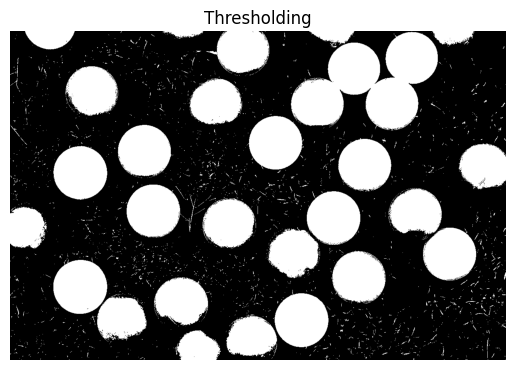

In [ ]:
import matplotlib.pyplot as plt

img = cv2.imread('gambar3.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# thresholding
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

# tampilkan
plt.imshow(thresh, cmap='gray')
plt.title('Thresholding')
plt.axis('off')
plt.show()

Text(0.5, 1.0, 'Segmented RGB')

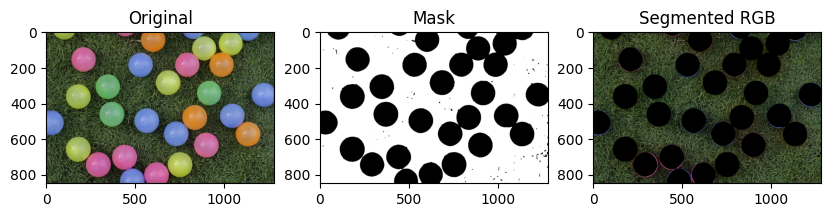

In [ ]:
img = io.imread('gambar3.jpg')
gray = color.rgb2gray(img)

cv = chan_vese(gray, mu=0.25)

mask = cv.astype(np.uint8)

segmented = img.copy()
segmented[mask == 0] = 0

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(img)
plt.title("Original")

plt.subplot(1,3,2)
plt.imshow(mask, cmap='gray')
plt.title("Mask")

plt.subplot(1,3,3)
plt.imshow(segmented)
plt.title("Segmented RGB")

Text(0.5, 1.0, 'Hasil Segmentasi')

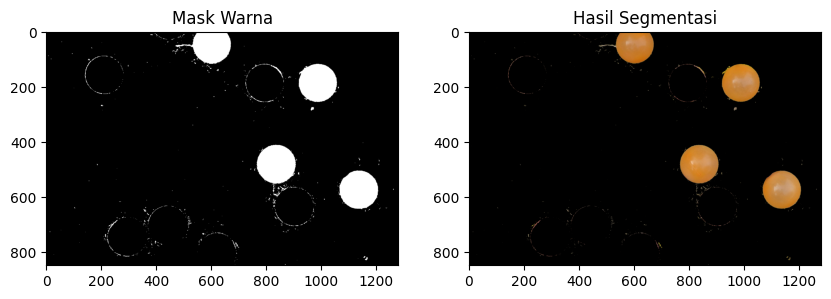

In [ ]:
img = cv2.imread('gambar3.jpg')
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

lower = np.array([0, 40, 50])
upper = np.array([25, 255, 255])

mask = cv2.inRange(hsv, lower, upper)
result = cv2.bitwise_and(img, img, mask=mask)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(mask, cmap='gray')
plt.title("Mask Warna")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
plt.title("Hasil Segmentasi")


(np.float64(-0.5), np.float64(1279.5), np.float64(847.5), np.float64(-0.5))

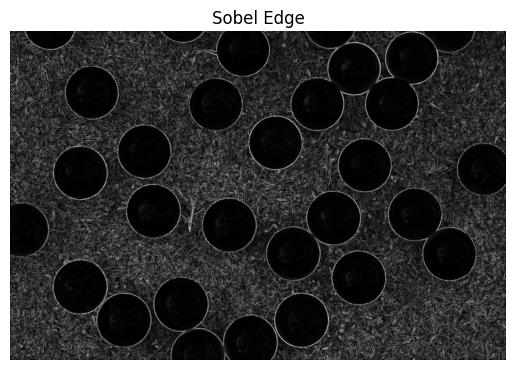

In [ ]:
img = cv2.imread('gambar3.jpg', 0)

sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=5)

sobel = cv2.magnitude(sobelx, sobely)

plt.imshow(sobel, cmap='gray')
plt.title("Sobel Edge")
plt.axis('off')


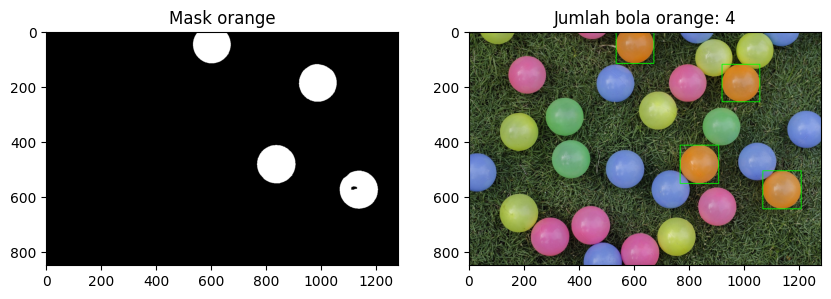

Jumlah bola orange: 4


In [ ]:

img = cv2.imread('gambar3.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Convert ke HSV
hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

# Range warna
lower_orange = np.array([10, 100, 100])
upper_orange = np.array([20, 255, 255])

# Mask warna
mask = cv2.inRange(hsv, lower_orange, upper_orange)

# Hapus noise
kernel = np.ones((5,5), np.uint8)
mask_clean = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
mask_clean = cv2.morphologyEx(mask_clean, cv2.MORPH_CLOSE, kernel)

# Deteksi contour
contours, _ = cv2.findContours(mask_clean, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Filter objek kecil (biar bukan noise)
count = 0
for cnt in contours:
    area = cv2.contourArea(cnt)
    if area > 300:  # threshold area (bisa disesuaikan)
        count += 1
        x,y,w,h = cv2.boundingRect(cnt)
        cv2.rectangle(img_rgb, (x,y), (x+w,y+h), (0,255,0), 2)

# Tampilkan hasil
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(mask_clean, cmap='gray')
plt.title("Mask orange")

plt.subplot(1,2,2)
plt.imshow(img_rgb)
plt.title(f"Jumlah bola orange: {count}")

plt.show()

print("Jumlah bola orange:", count)